## Time to get your hands dirty! Supernova distances and redshifts (part 2)

In [212]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format='retina'

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_26966/417715501.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

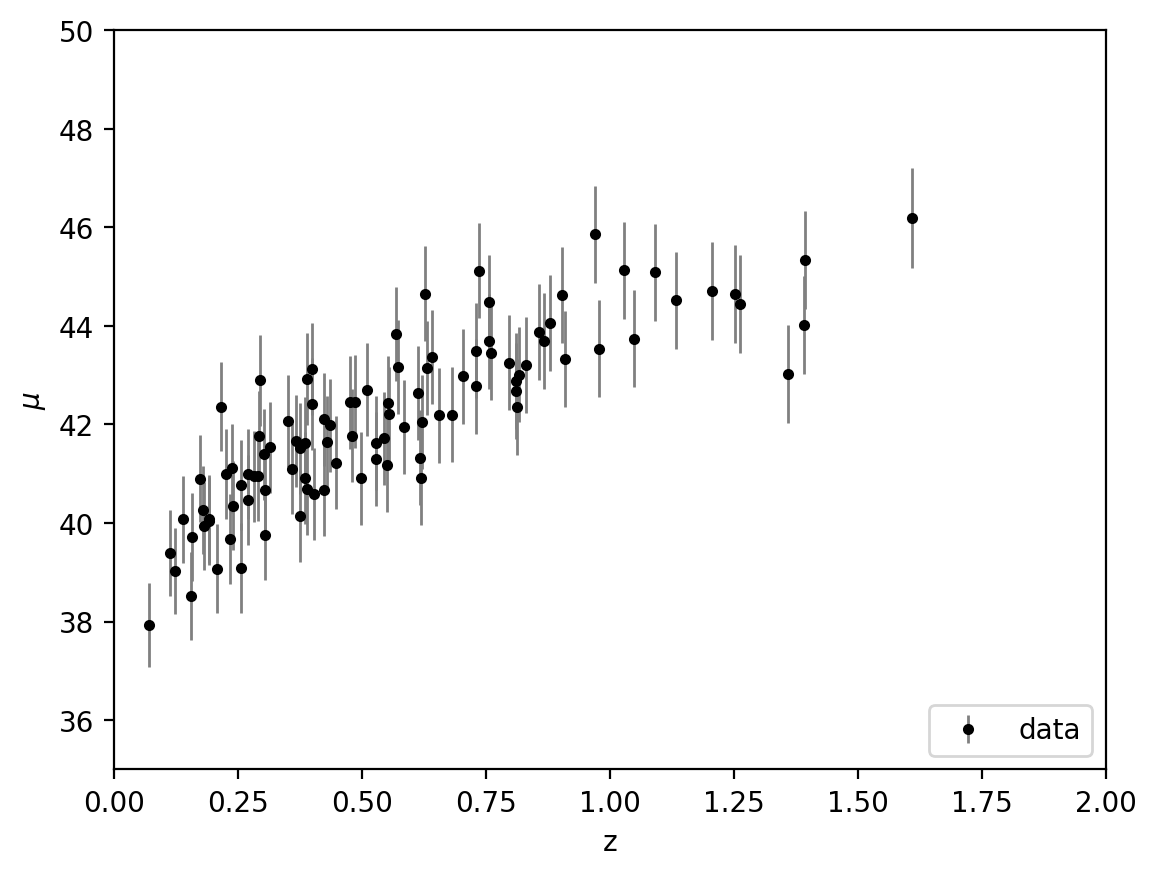

In [213]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=42)

data = (z_sample, mu_sample, dmu)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)


First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Check out what's available in the `kernels` submodule of [sklearn.gaussian_process](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.gaussian_process)
- *Hint*. Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

*Note*. We have time constraints, so feel free to tweak the hyperparameters manually while in class. But, of course, a publication-quality result will require a cross-validation analysis. (Do this at home before the exam?)

In [214]:
# sklearn format
X = z_sample[:, np.newaxis]
y = mu_sample
alpha = dmu**2  # variance

RBF(length_scale=2.58)
RationalQuadratic(alpha=0.1, length_scale=2.34)
Matern(length_scale=5.48, nu=1)


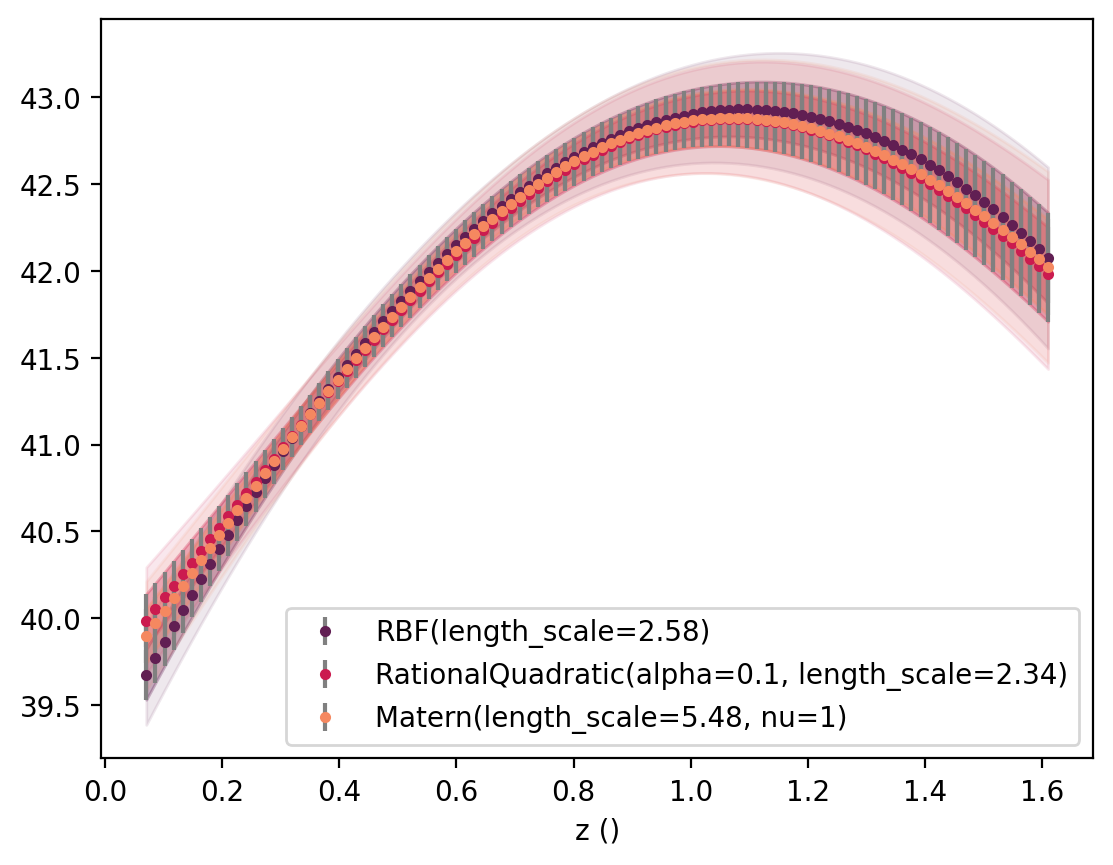

In [215]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, RationalQuadratic, Matern

# Radial Basis Function (https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.RBF.html)
# RQ -> RBF when alpha->inf (https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.Matern.html#sklearn.gaussian_process.kernels.Matern)
# Matern -> RBF when nu ->inf (https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.Matern.html)
kernels = [RBF(length_scale=2.52),
           RationalQuadratic(alpha=0.1, length_scale=2.52, alpha_bounds="fixed"), #fixing alpha so RQ != RBF
           Matern(length_scale=100, nu=1.0)]                                      #fixing nu so Matern != RBF

palette = sns.color_palette("rocket", len(kernels))

xgrid = np.linspace(z_sample.min(), z_sample.max(), 100)

for kernel, c in zip(kernels, palette):

    gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha, random_state=42)
    gp.fit(X,y)
    y_pred, dy_pred = gp.predict(xgrid[:, np.newaxis], return_std=True)

    # print(y_pred, dy_pred)

    plt.errorbar(
        xgrid,
        y_pred,
        yerr=dy_pred,
        fmt='.',
        color=c,
        ecolor="grey",
        label=gp.kernel_
    )
    print(gp.kernel_)


    #plotting bounds
    plt.fill_between(xgrid, y_pred - dy_pred, y_pred + dy_pred,
                     color=c, alpha=0.3)

    plt.fill_between(xgrid, y_pred - 2*dy_pred, y_pred + 2*dy_pred,
                     color=c, alpha=0.1)
    
    # break

plt.legend()
plt.xlabel("z ()")
plt.show()


We now have a suite of **data-driven** predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

This is already great and these kind of tools are immensely useful in a variety of contexts (also involving a lot of money: suppose you want to predict how much a give financial asset will perform on tomorrow's stock market... You  might not really care about expressing the underlying financial model in simple terms, as long as your investments are profitable).

For the case of supernovae, however, we have do have physical theory which is $\Lambda$CDM. We can do a **parametric** fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

- First, refresh your cosmology and write down the predicted relationship between the distance module $\mu$ and the redshift $\sigma$. *Hint* I always forget these things, my to-go reference is [Hogg (2010)](https://arxiv.org/abs/astro-ph/9905116). I got:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$


- Assuming a flat Universe,  we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$
- It's a very non-linear model. Fit it to the data (however you want to do it, are you frequentist or Bayesian after all?).
- What are the measured value of $H_0$ and $\Omega_m$. <mark>Are they correlated? </mark>

In [216]:
# --------- LAMBDA CDM MODEL ------------

from scipy.integrate import quad
import numpy as np

C_LIGHT = 3e5  # km/s

# from https://arxiv.org/pdf/1903.12097
initial_vals = np.array([67.4, 0.14])  # H0 in km/s/Mpc, OmegaM nondim
initial_sigmas = np.array([6.0, 0.06]) #assuming symmetric uncertainty

def model(z, par):
    H0, Om = par
    if H0 <= 0 or not (0 <= Om <= 1):
        return np.full_like(z, np.nan, float)

    Ol = 1 - Om
    f = lambda x: 1/np.sqrt(Om*(1+x)**3 + Ol)

    z = np.asarray(z, float)

    return np.array([
        np.nan if zi < 0 else 5*np.log10((C_LIGHT/(H0*1e-5))*(1+zi)*quad(f, 0, zi)[0])
        for zi in z
    ], float)


# **CHI SQUARE**

Best-fit H0, OmegaM: [59.74876249  0.90808794]


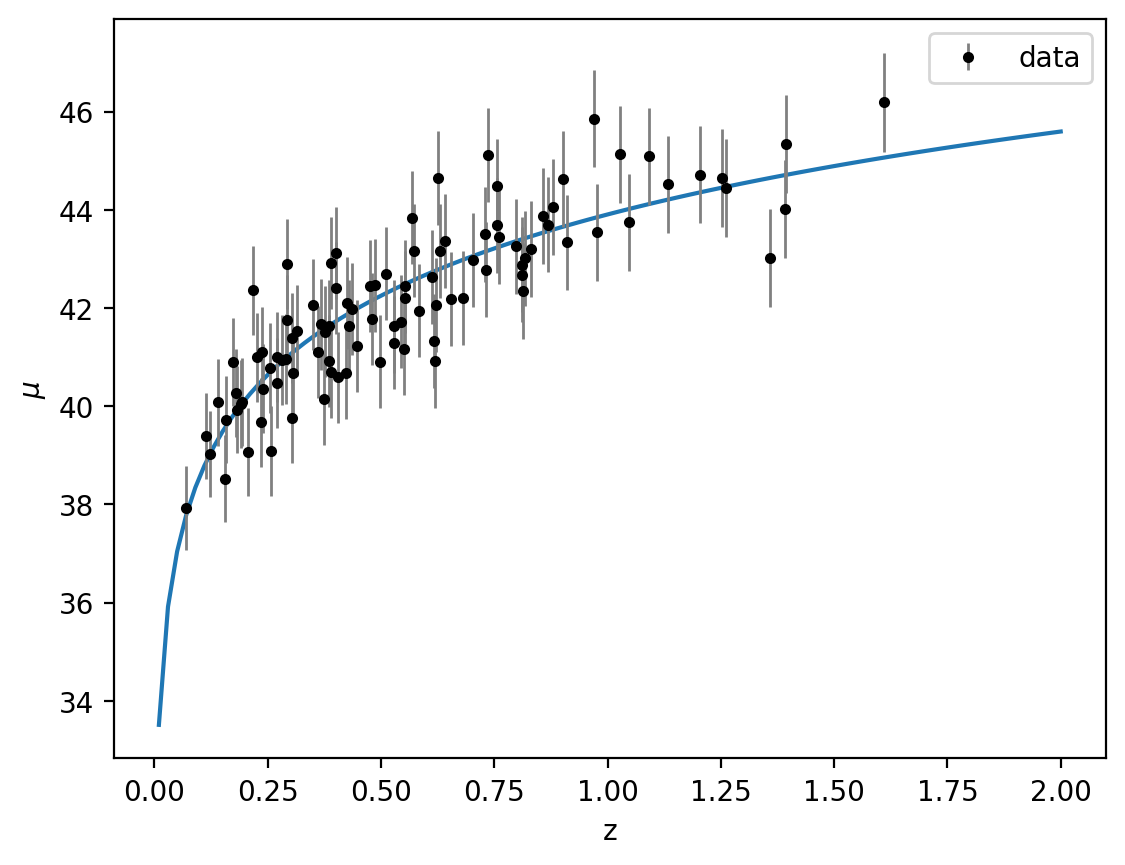

In [217]:
from scipy.optimize import minimize

def chi2(par):
    H0, Om = par
    if H0<=0 or Om<0 or Om>1: 
        return np.inf
    mu_fit = model(z_sample, par)
    return np.sum(((mu_sample - mu_fit)/dmu)**2)

res = minimize(chi2, x0=[67,0.3], bounds=[(50,90),(0,1)])

print("Best-fit H0, OmegaM:", res.x)


zgrid = np.linspace(0.01,2,100)

plt.plot(zgrid, model(zgrid, res.x))
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.legend()
plt.show()


# **MCMC**

In [218]:
# ------ MCMC SETUP ----------

def logLikelihood(par):
    mu_fit = model(z_sample, par)

    if np.any(np.isnan(mu_fit)):
        return -np.inf

    return -0.5 * np.sum((mu_sample - mu_fit)**2 / dmu**2)


#considering gaussian priors for H0 and OmegaM
def logPrior(par):
    H0, OmegaM = par
    # Hard bounds: H0>0, 0<=OmegaM<=1
    if not (30 < H0 < 100) or not (0 <= OmegaM <= 1):
        return -np.inf  # reject
    lp = -0.5 * ((H0 - initial_vals[0])**2 / initial_sigmas[0]**2
                 + (OmegaM - initial_vals[1])**2 / initial_sigmas[1]**2)
    return lp


# !! not tracking renormalisation, just finding best fit params
def logPosterior(par):
    return logLikelihood(par) + logPrior(par)

In [219]:
import emcee

#---------------- MCMC walkers ----------------
ndim = 2
nwalkers = 10
nsteps = 5000

# initialising walkers
starting_guesses = np.column_stack([
    np.random.normal(initial_vals[0], initial_sigmas[0], size=nwalkers),
    np.random.normal(initial_vals[1], initial_sigmas[1], size=nwalkers)
])

In [220]:
# ---------- RUNNING MCMC -----------
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior)
sampler.run_mcmc(starting_guesses, nsteps, progress=True)

#---------------- Extract results ----------------
samples = sampler.get_chain(flat=True)
print("Posterior samples shape:", samples.shape)
print("Example posterior mean:", np.mean(samples, axis=0))

100%|██████████| 5000/5000 [01:38<00:00, 50.78it/s]

Posterior samples shape: (50000, 2)
Example posterior mean: [72.15736559  0.18684578]


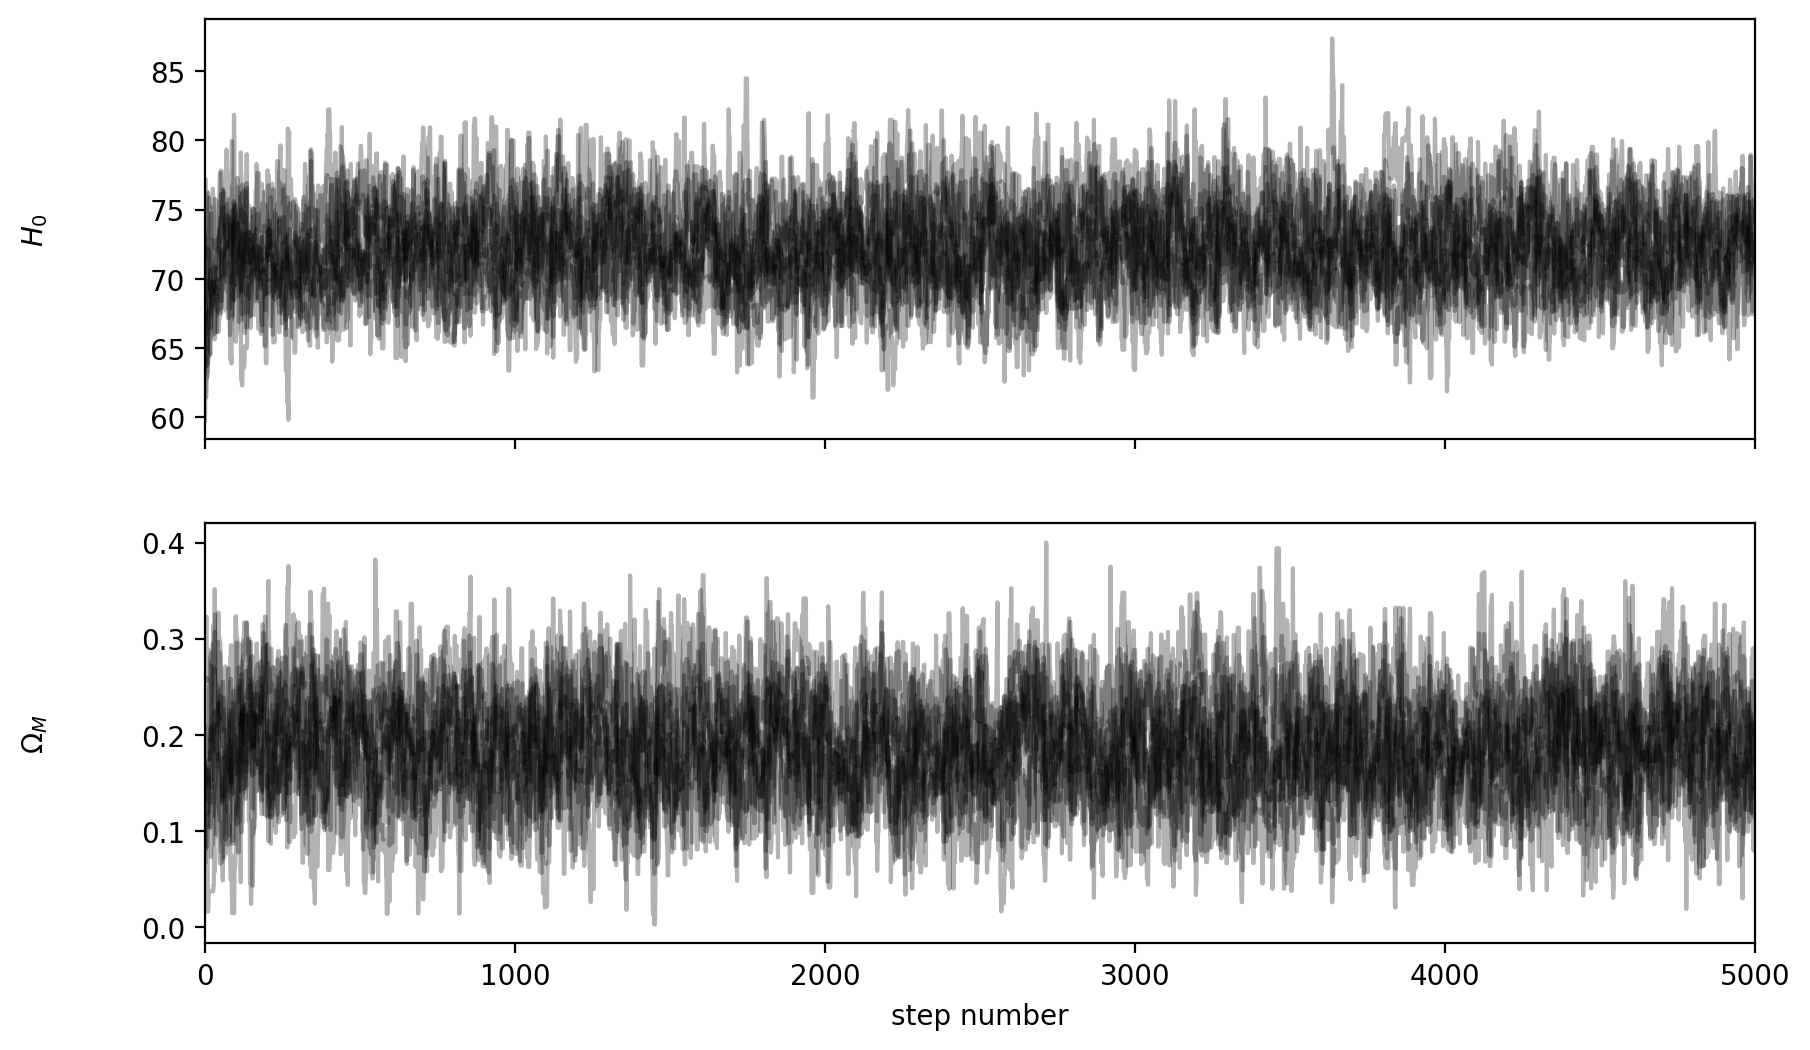

In [221]:
#----------- PRELIMINARY PLOTTING---------------
fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True)
#getting the whole chain
samples = sampler.get_chain()
labels = ["$H_0$", "$\\Omega_{M}$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");


In [222]:
#------------ ANALYSING RESULTS ----------------
burn = int(nsteps*nwalkers/500) # "burn-in" period to let chains stabilize
print(f"burn: {burn}")

# Get the autocorrelation times
autocorr = sampler.get_autocorr_time()
print("Autocorrelation times:", autocorr)

# Calculate a single thinning value as the maximum autocorrelation time
thin = int(np.ceil(np.max(autocorr))) + 1  # Use the maximum autocorr rounded up

# Get the trace after discarding the burn-in and applying thinning
emcee_trace = sampler.get_chain(discard=burn, thin=thin, flat=True)

burn: 100
Autocorrelation times: [33.77184402 28.55390115]


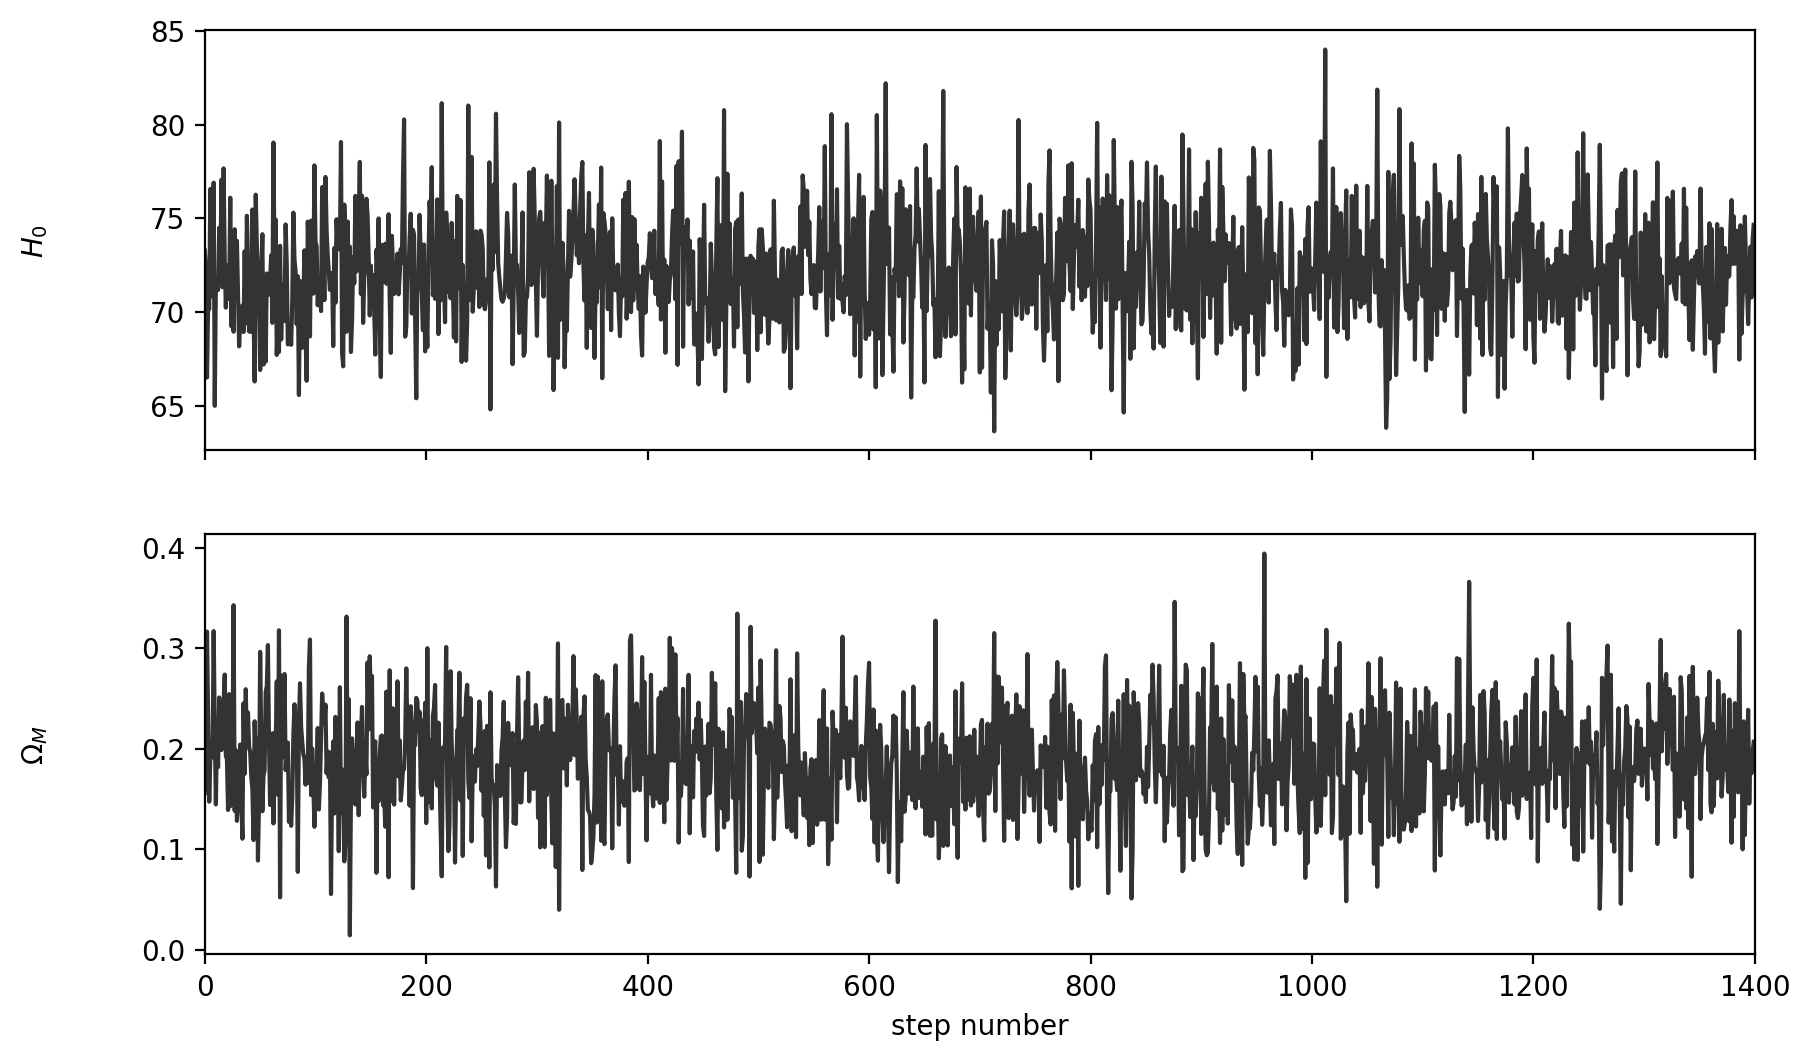

In [223]:
fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True)


labels = ["$H_0$", "$\\Omega_{M}$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(emcee_trace[:, i], "k", alpha=0.8)
    ax.set_xlim(0, len(emcee_trace))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");


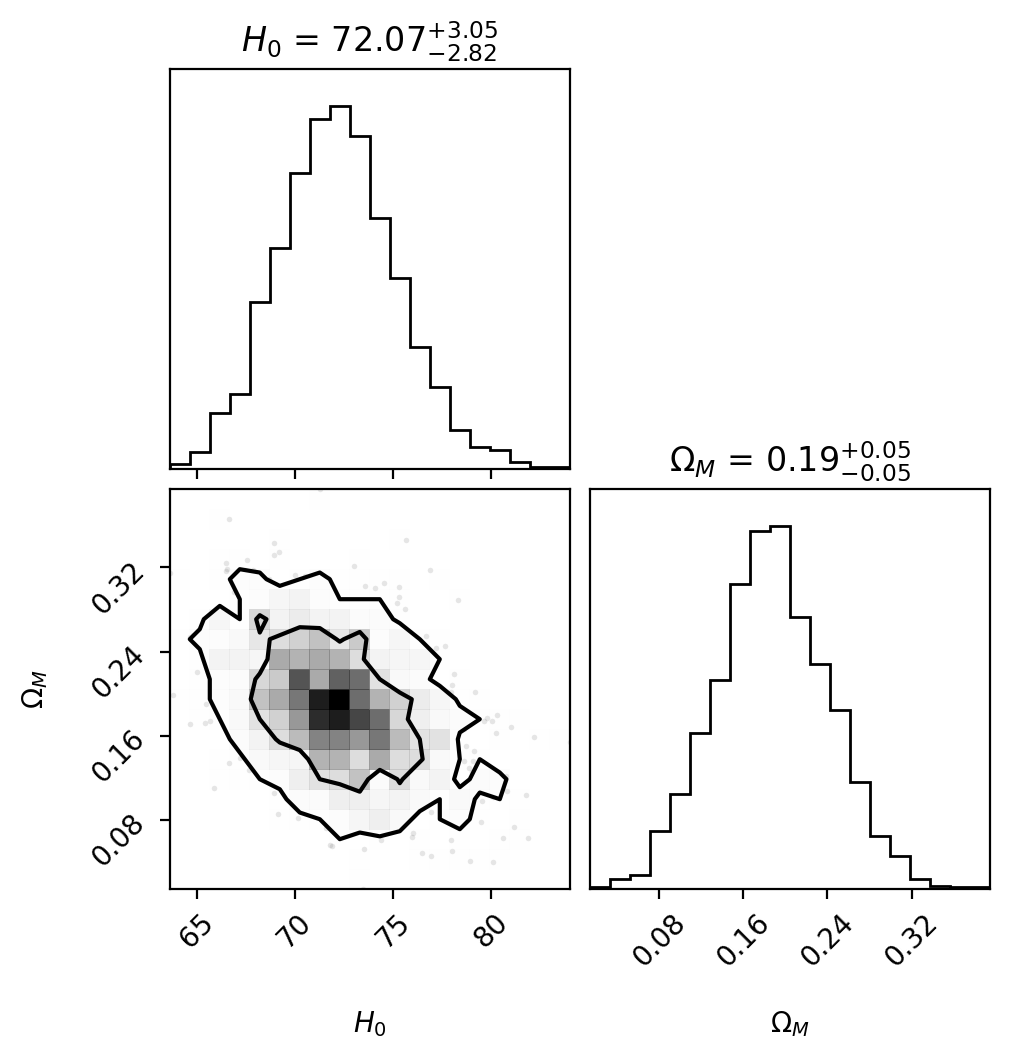

In [224]:
#-------------- CORNER PLOT --------------
from corner import corner
corner(emcee_trace, labels=labels,levels=[0.68,0.95], show_titles=True)
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_26966/3718757336.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_26966/3186755014.py:23: RuntimeWarning: divide by zero encountered in log10
  np.nan if zi < 0 else 5*np.log10((C_LIGHT/(H0*1e-5))*(1+zi)*quad(f, 0, zi)[0])


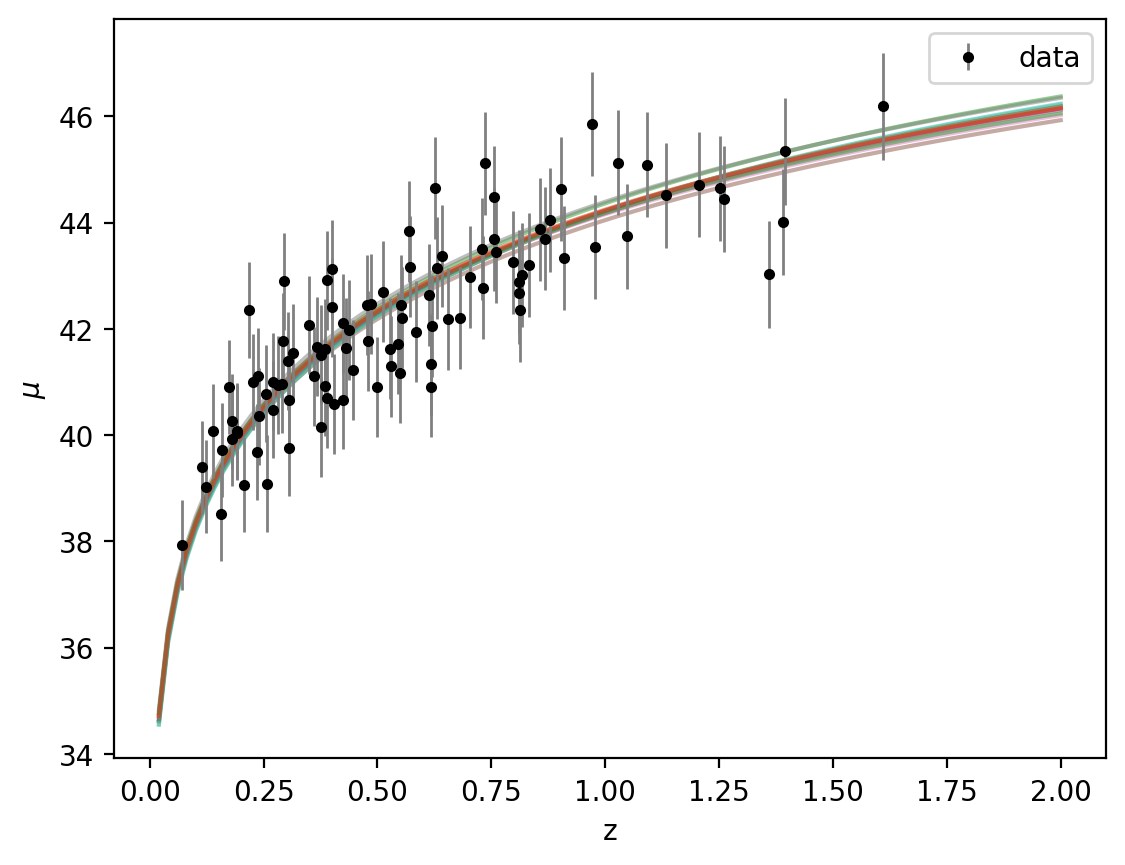

In [225]:
# ----------- PLOTTING A FEW RESULTS -----------
zgrid = np.linspace(0,2,100)

for par in emcee_trace[::100]:
    plt.plot(zgrid, model(zgrid, par),alpha=0.5)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend()
plt.show()

# **NESTED SAMPLING**

In [226]:
import dynesty
from scipy import stats

In [227]:
# inverse of the prior
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)` (2D)
    to the parameters of interest (gaussian)."""

    x = np.array(u)
    #using scipy.stats percent point function (inverse of cdf)
    for i in range(len(x)):
       x[i] = stats.uniform(
                loc=initial_vals[i],
                scale=initial_sigmas[i]
            ).ppf(u[i])
    return x

In [228]:
#------------ RUNNNING NESTED SAMPLING --------------
ndim=2
sampler = dynesty.NestedSampler(logLikelihood, ptform, ndim, nlive=1000)
sampler.run_nested()
results = sampler.results

1093it [00:05, 197.17it/s, +1000 | bound: 0 | nc: 1 | ncall: 3993 | eff(%): 69.930 | loglstar:   -inf < -41.736 <    inf | logz: -42.558 +/-    nan | dlogz:  0.001 >  1.009]


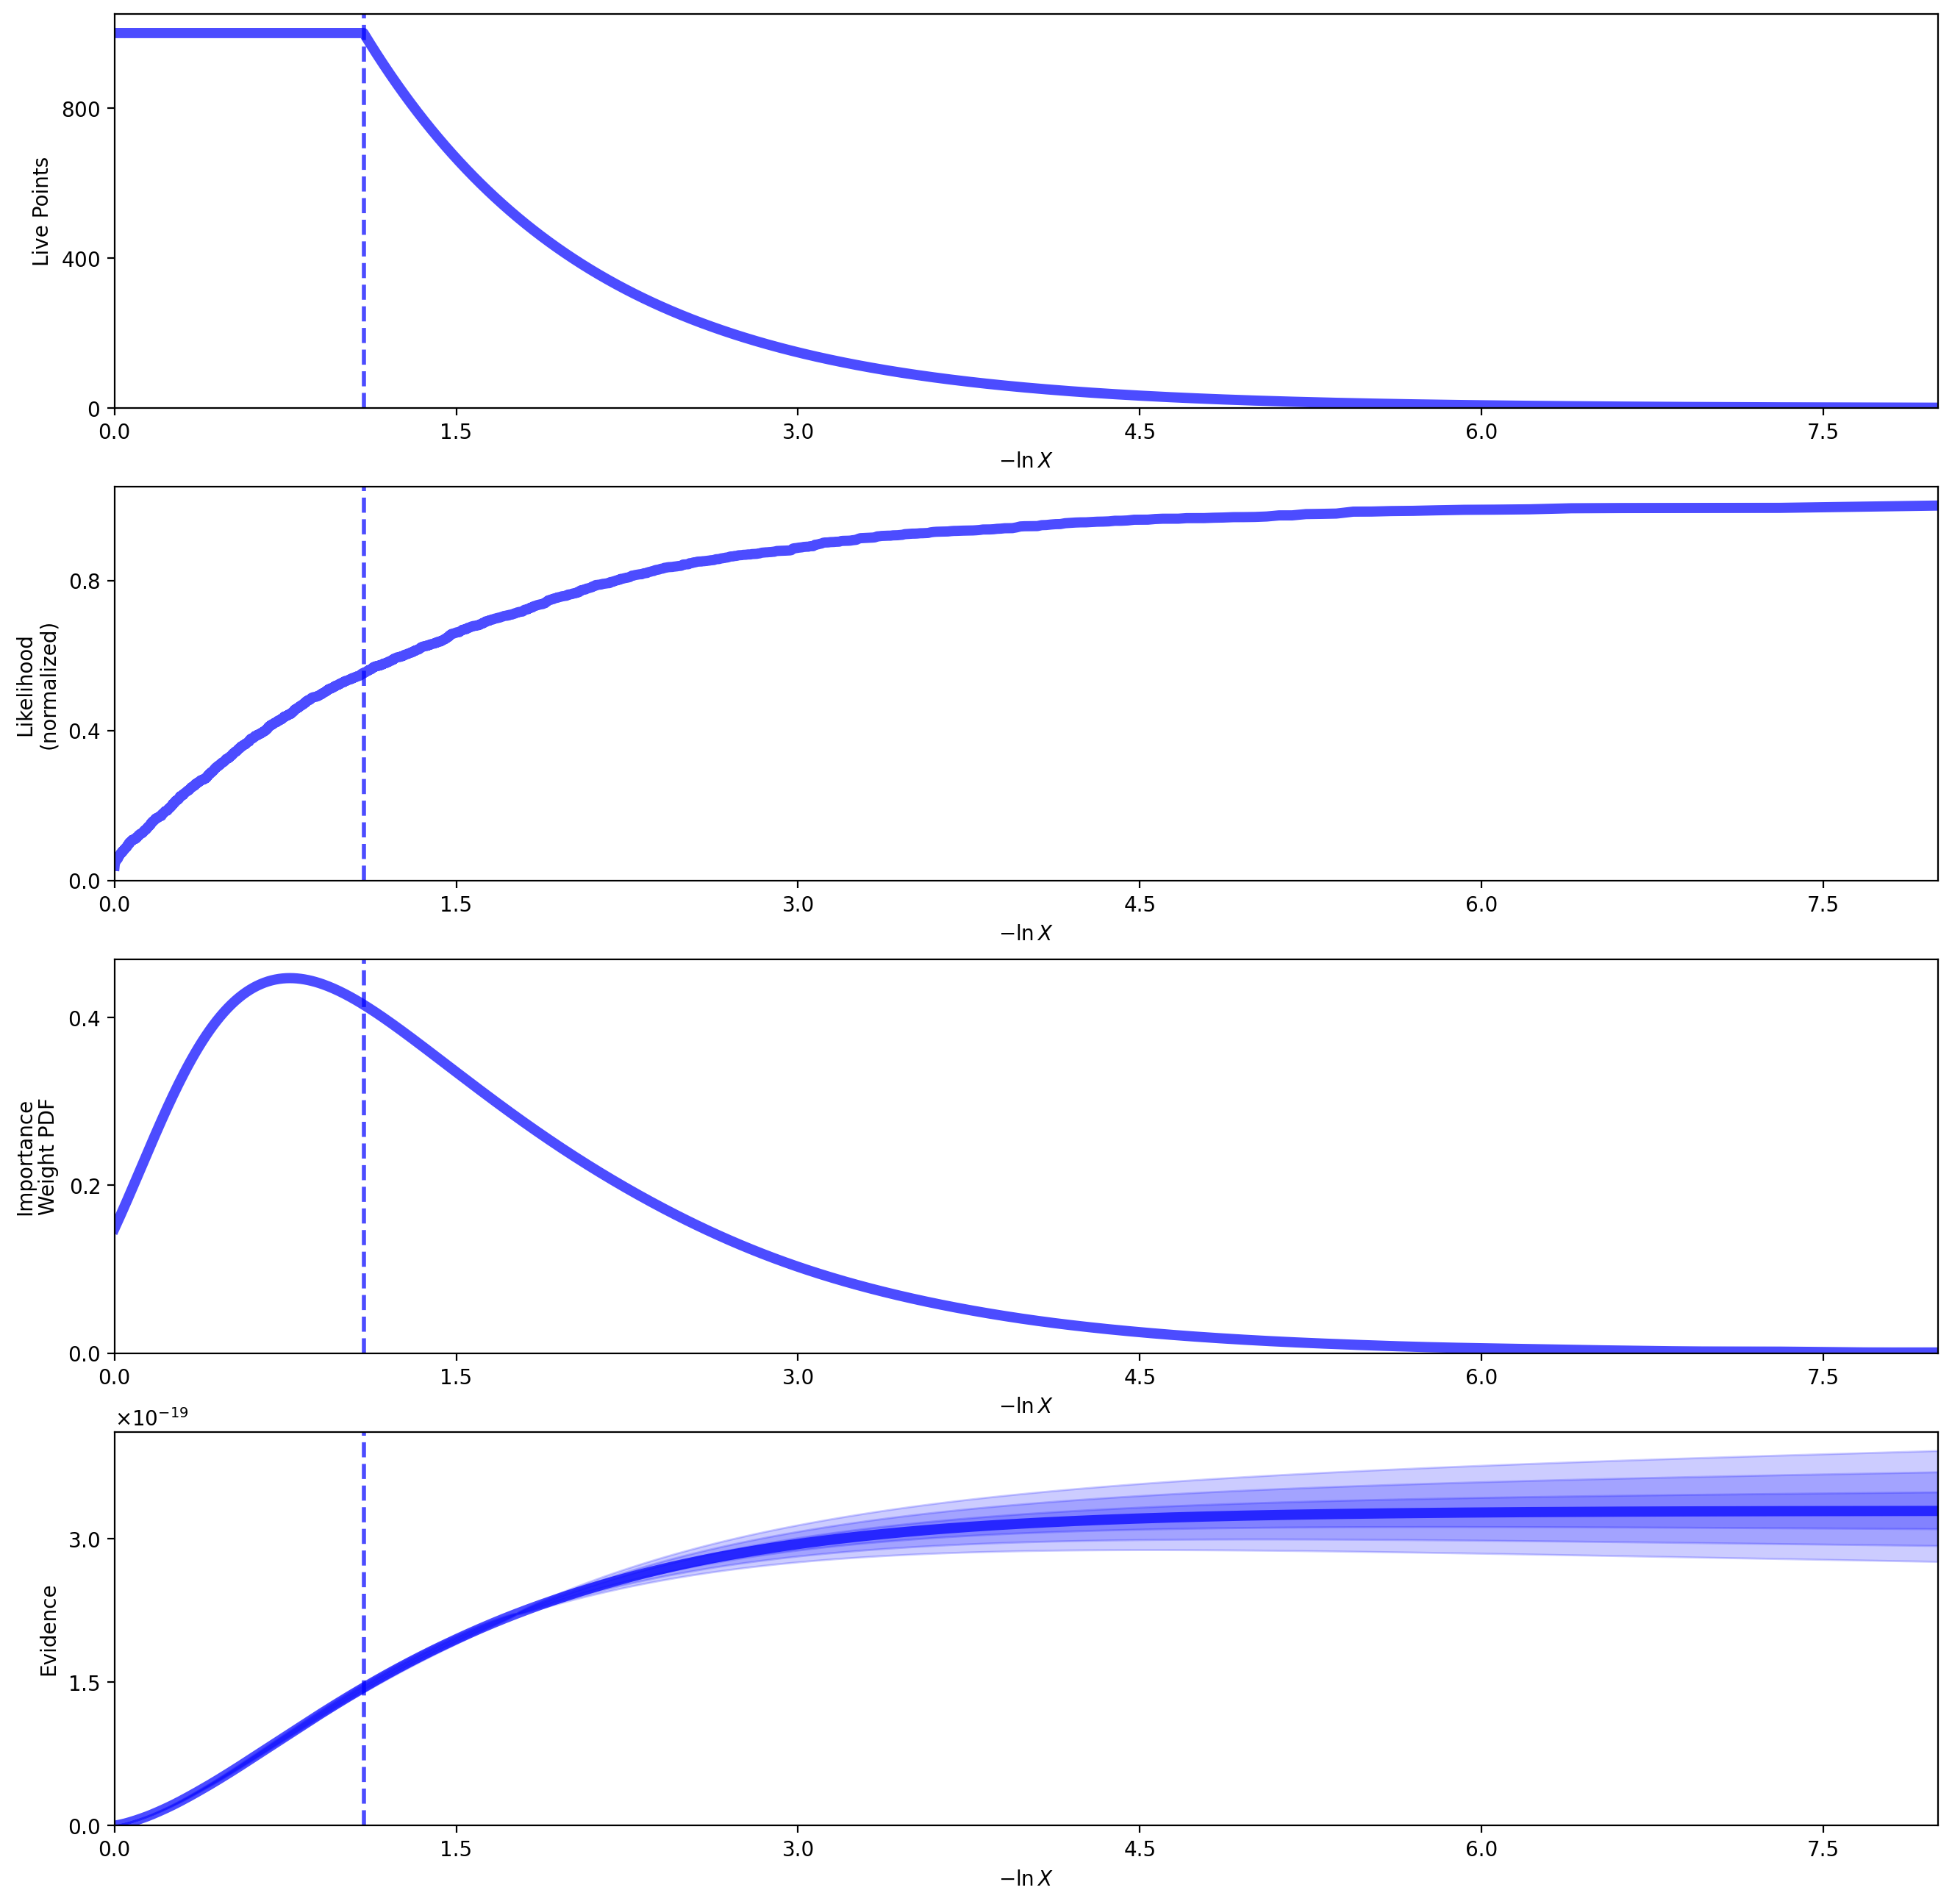

In [229]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(results)

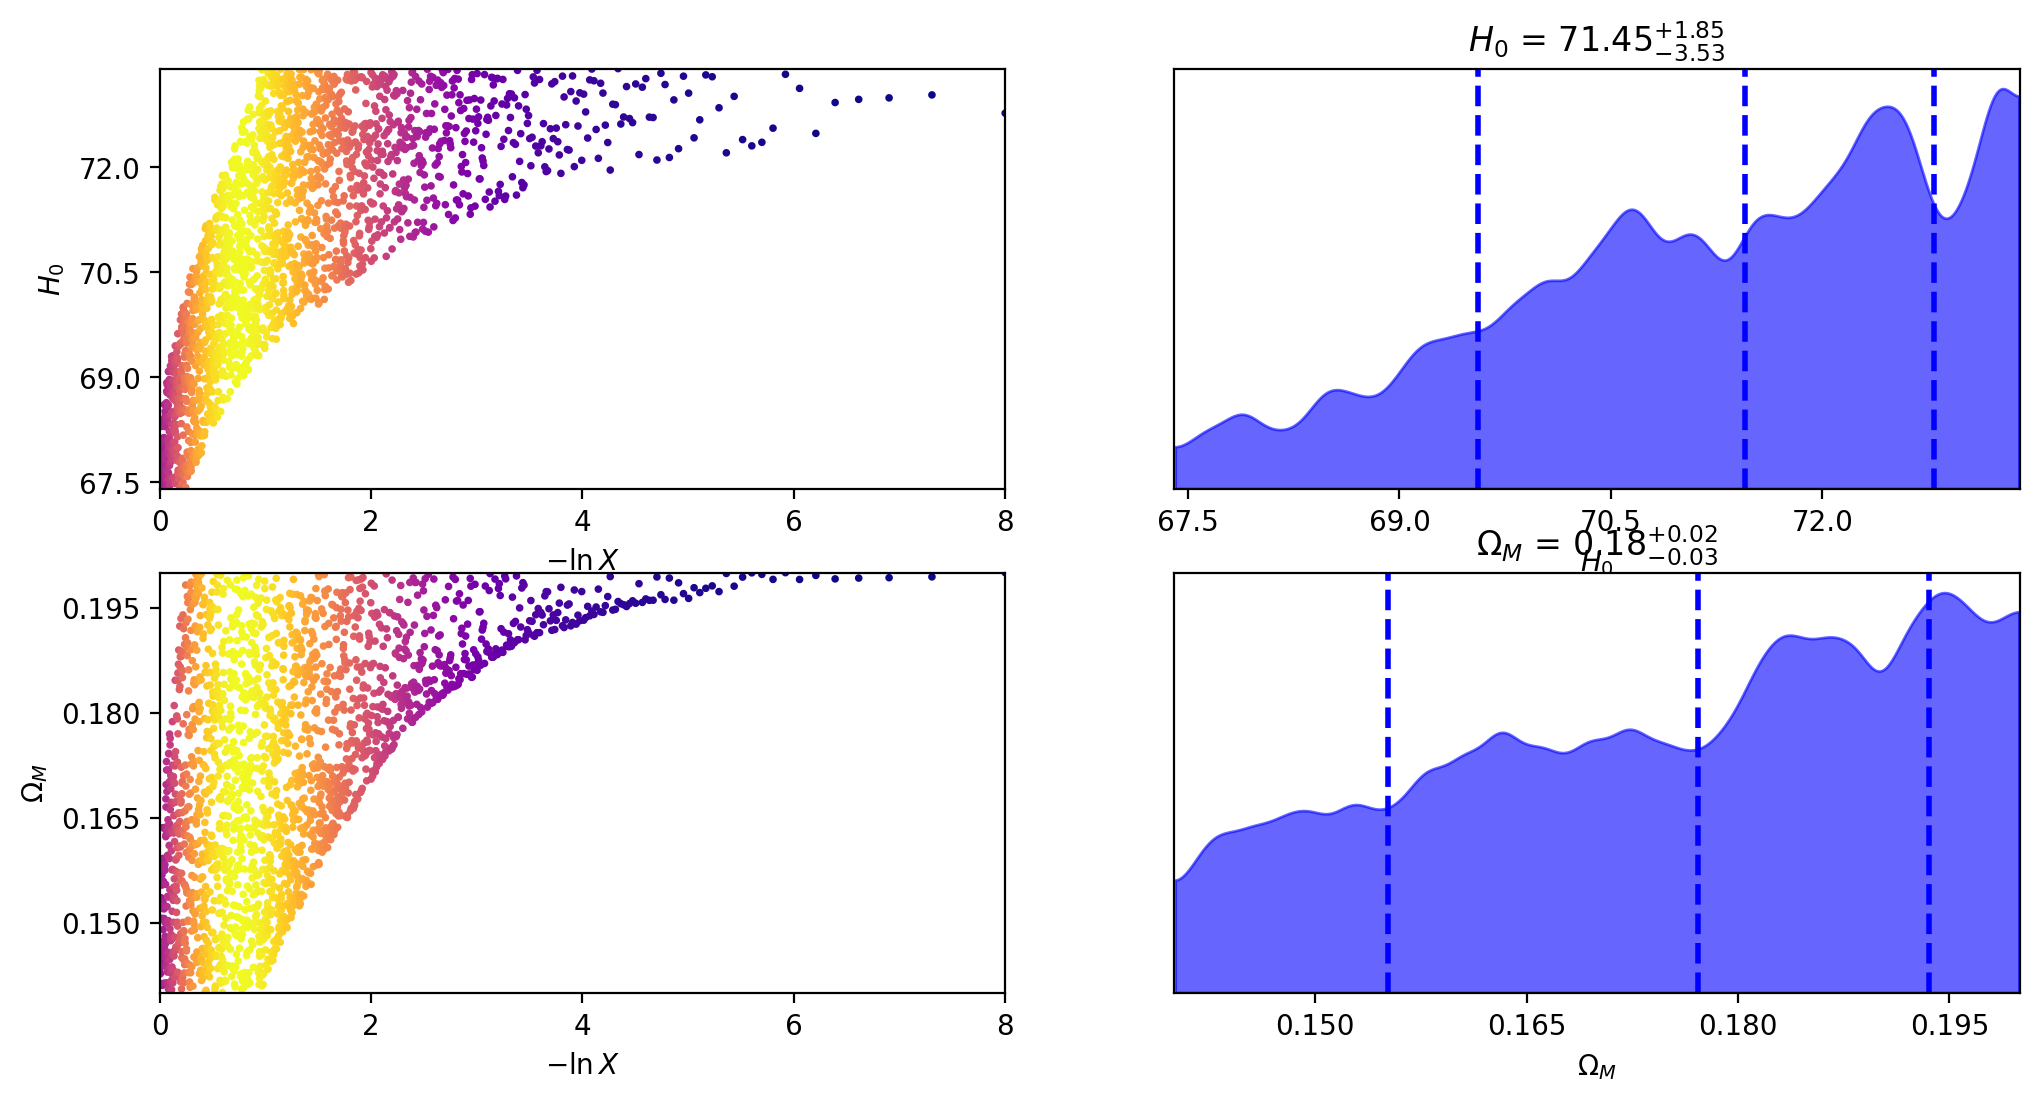

In [230]:
labels = ["$H_0$", "$\\Omega_{M}$"]
tfig, taxes = dyplot.traceplot(sampler.results, labels=labels, show_titles=True, quantiles=[0.16, 0.5, 0.84])

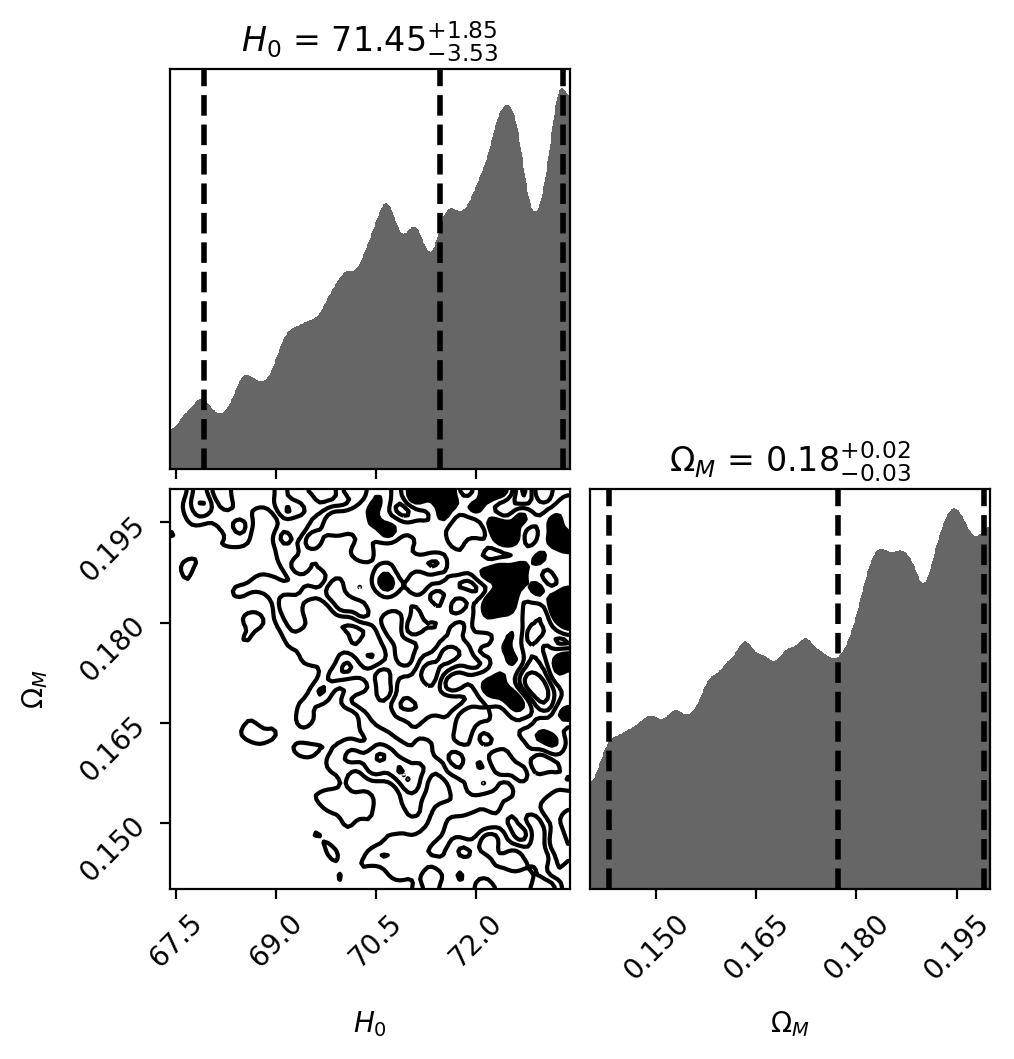

In [231]:
cfig, caxes = dyplot.cornerplot(sampler.results, labels=labels, show_titles=True, )

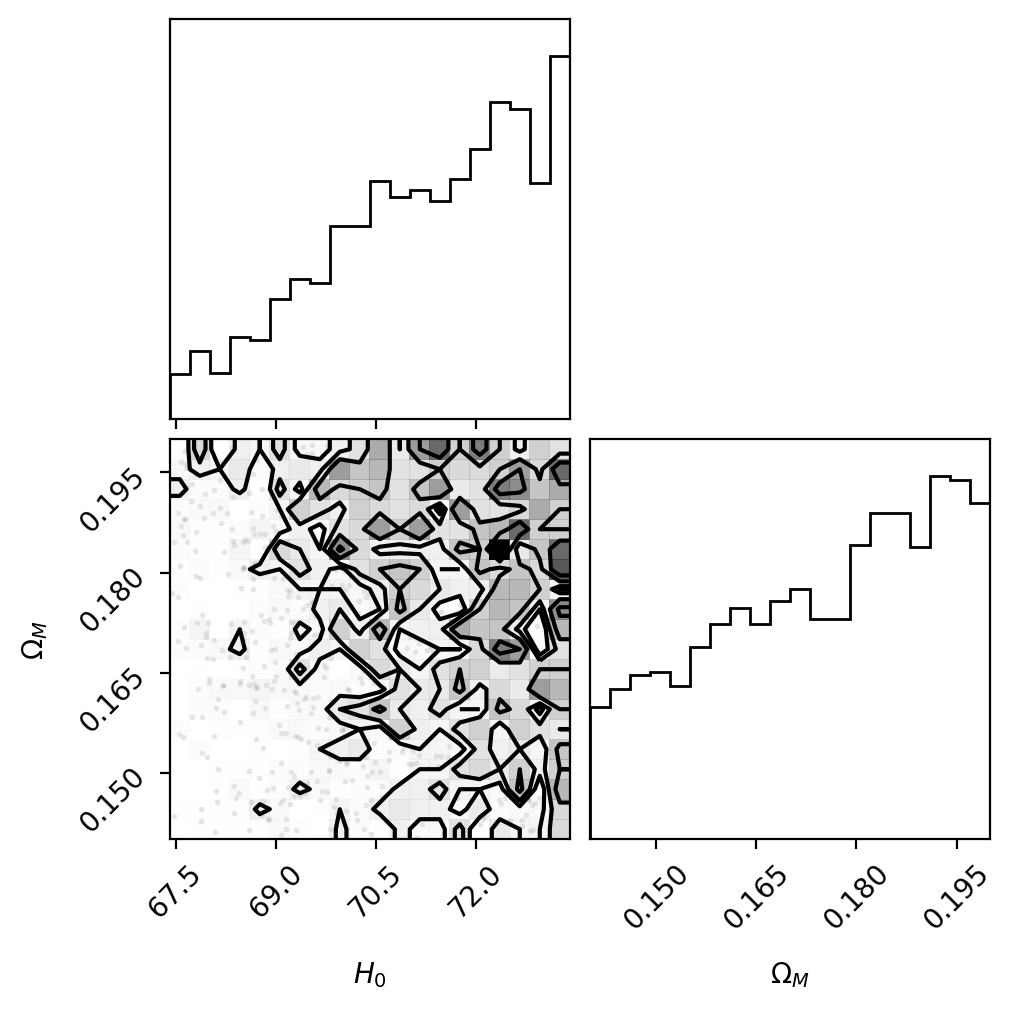

In [232]:
from dynesty import utils as dyfunc
from corner import corner

samples = results.samples
weights = np.exp(results.logwt - results.logz[-1])  # normalized weights

samples_equal = dyfunc.resample_equal(samples, weights)
corner(samples_equal,labels=labels);

/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_26966/3186755014.py:23: RuntimeWarning: divide by zero encountered in log10
  np.nan if zi < 0 else 5*np.log10((C_LIGHT/(H0*1e-5))*(1+zi)*quad(f, 0, zi)[0])


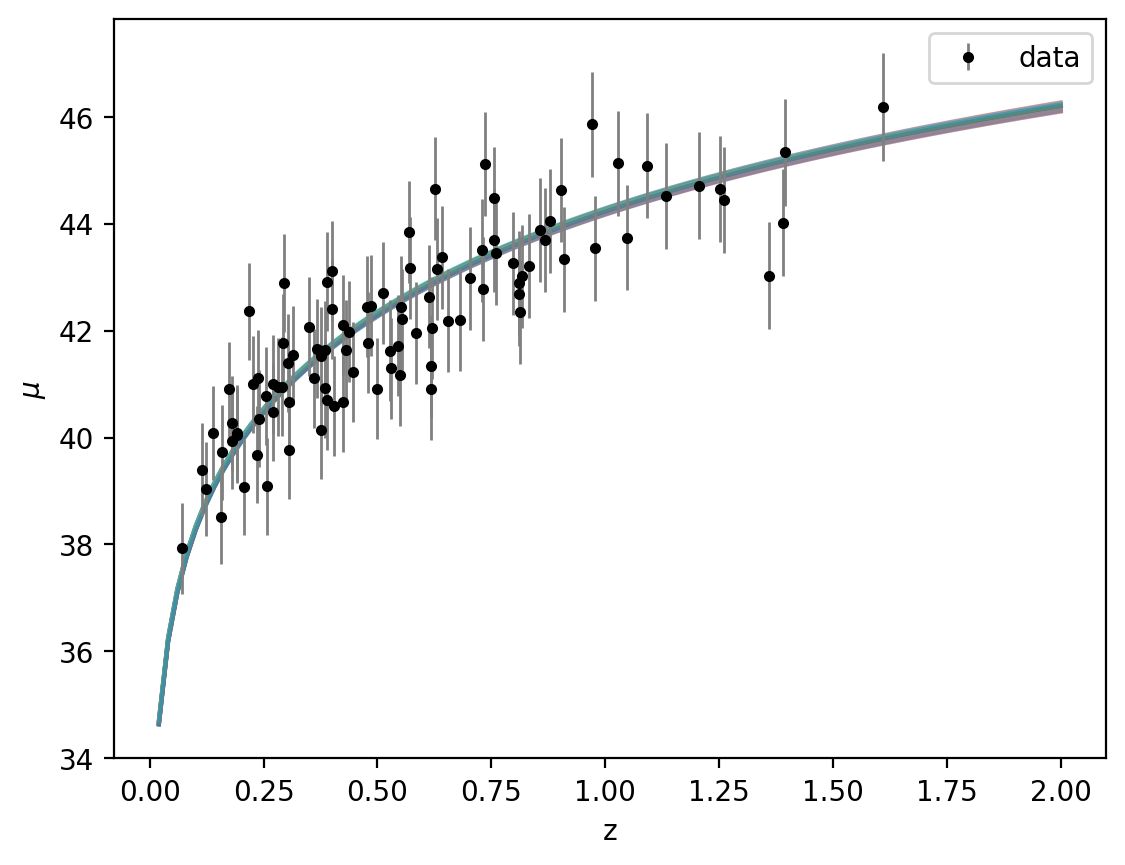

In [243]:
# ----------- PLOTTING A FEW RESULTS -----------
zgrid = np.linspace(0,2,100)

for par in samples_equal[::100]:
    plt.plot(zgrid, model(zgrid, par),alpha=0.5)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.legend()
plt.show()

## **DARK ENERGY?**
- How would a model without dark energy (i.e. $\Omega_m=1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem!)

In [234]:
def model1(z, par):
    H0, Om = float(par), 1.
    if H0 <= 0 or not (0 <= Om <= 1.0001):
        return np.full_like(z, np.nan, float)

    Ol = 1 - Om
    f = lambda x: 1/np.sqrt(Om*(1+x)**3 + Ol)

    z = np.asarray(z, float)

    return np.array([
        np.nan if zi < 0 else 5*np.log10((C_LIGHT/(H0*1e-5))*(1+zi)*quad(f, 0, zi)[0])
        for zi in z
    ], float)


def logLikelihood1(par):
    mu_fit = model1(z_sample, par)

    if np.any(np.isnan(mu_fit)):
        return -np.inf

    return -0.5 * np.sum((mu_sample - mu_fit)**2 / dmu**2)


In [235]:
#------------ RUNNNING NESTED SAMPLING --------------
ndim=1
sampler1 = dynesty.NestedSampler(logLikelihood1, ptform, ndim, nlive=1000)
sampler1.run_nested()
results1 = sampler1.results

/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_26966/3023649505.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H0, Om = float(par), 1.
2180it [00:18, 118.87it/s, +1000 | bound: 0 | nc: 1 | ncall: 10075 | eff(%): 35.041 | loglstar:   -inf < -45.303 <    inf | logz: -47.233 +/-  0.025 | dlogz:  0.001 >  1.009]


In [236]:
# from dynesty import plotting as dyplot

# rfig1, raxes1 = dyplot.runplot(results1)

In [237]:
# labels1 = ["$H_0$"]
# tfig1, taxes1 = dyplot.traceplot(results1, labels=labels1, show_titles=True, quantiles=[0.16, 0.5, 0.84])

In [238]:
# cfig1, caxes1 = dyplot.cornerplot(results1, labels=labels1, show_titles=True)

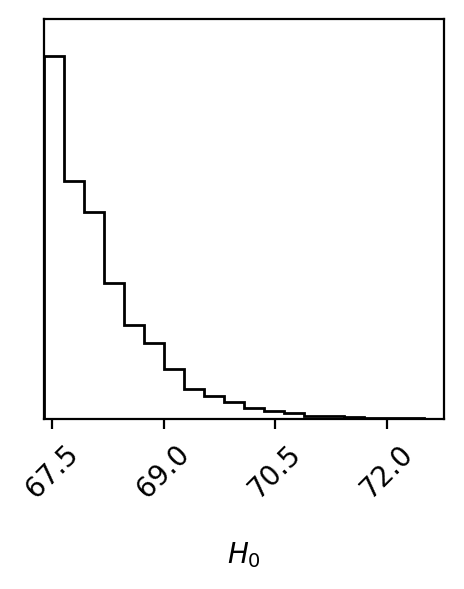

In [239]:
from dynesty import utils as dyfunc
from corner import corner

labels1 = ["$H_0$"]

samples1 = results1.samples
weights1 = np.exp(results1.logwt - results1.logz[-1])  # normalized weights

samples_equal1 = dyfunc.resample_equal(samples1, weights1)
corner(samples_equal1,labels=labels1);

/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_26966/3023649505.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H0, Om = float(par), 1.
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_26966/3023649505.py:12: RuntimeWarning: divide by zero encountered in log10
  np.nan if zi < 0 else 5*np.log10((C_LIGHT/(H0*1e-5))*(1+zi)*quad(f, 0, zi)[0])


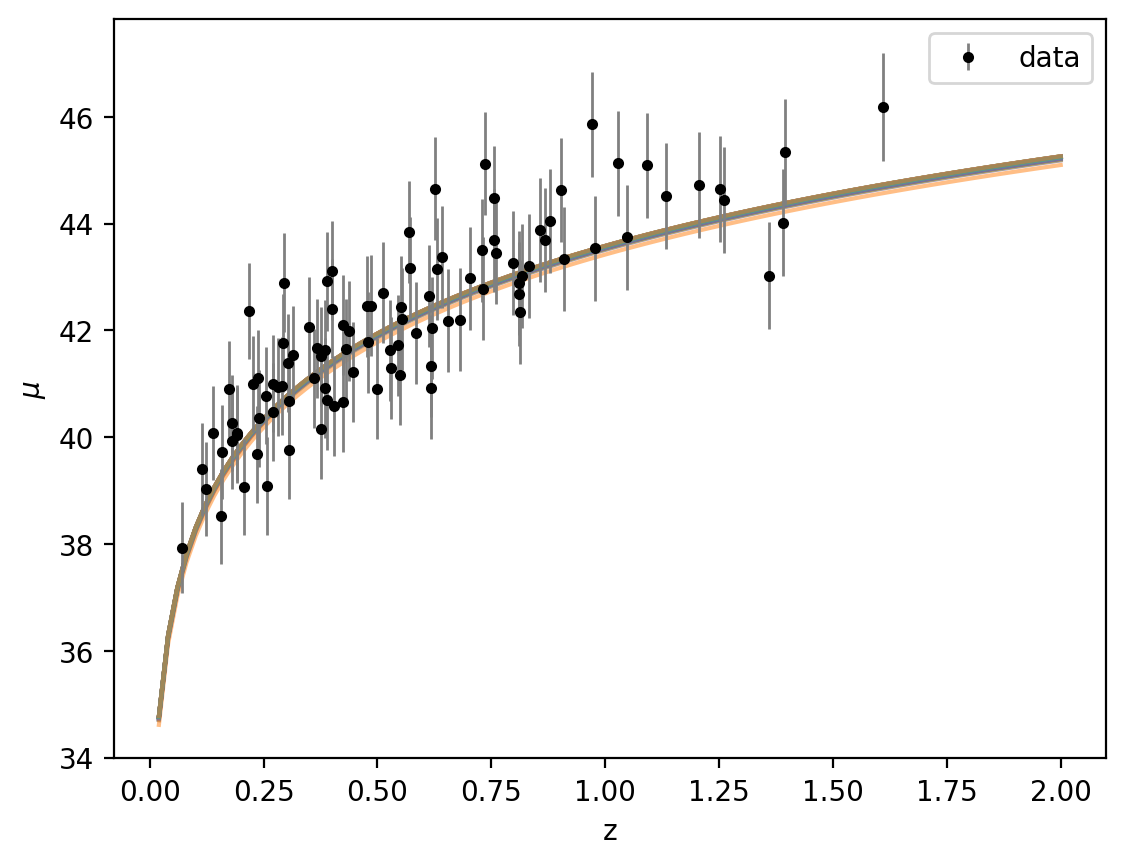

In [245]:
# ----------- PLOTTING A FEW RESULTS -----------
zgrid = np.linspace(0,2,100)

for par in samples_equal1[::100]:
    plt.plot(zgrid, model1(zgrid, par),alpha=0.5)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.legend()
plt.show()

In [ ]:
np.exp(results.logz[-1])/np.exp(results1.logz[-1])

107.18201545233129

overwhelming evidence for dark matter!

# **MORE DATA!**


The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.
- Think about the pdf of these data in $z$.
- Using both the GPR fit and your latest $\Lambda$CDM fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given. 

## DENSITY ESTIMATION

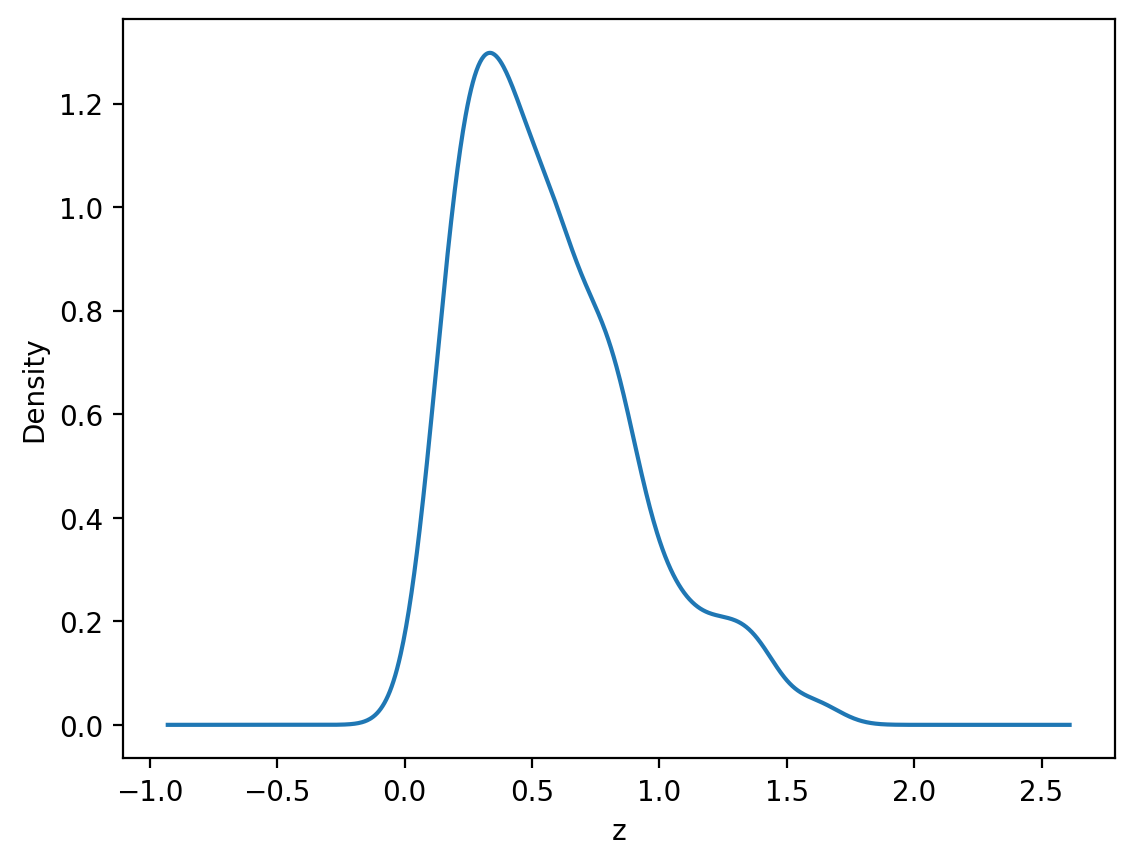

In [241]:
from sklearn.neighbors import KernelDensity

z_vals = np.array(z_sample).reshape(-1, 1) 

kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_vals)

z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)

plt.plot(z_plot[:, 0], dens)
plt.xlabel('z')
plt.ylabel('Density')
plt.show()

### GPR cloning

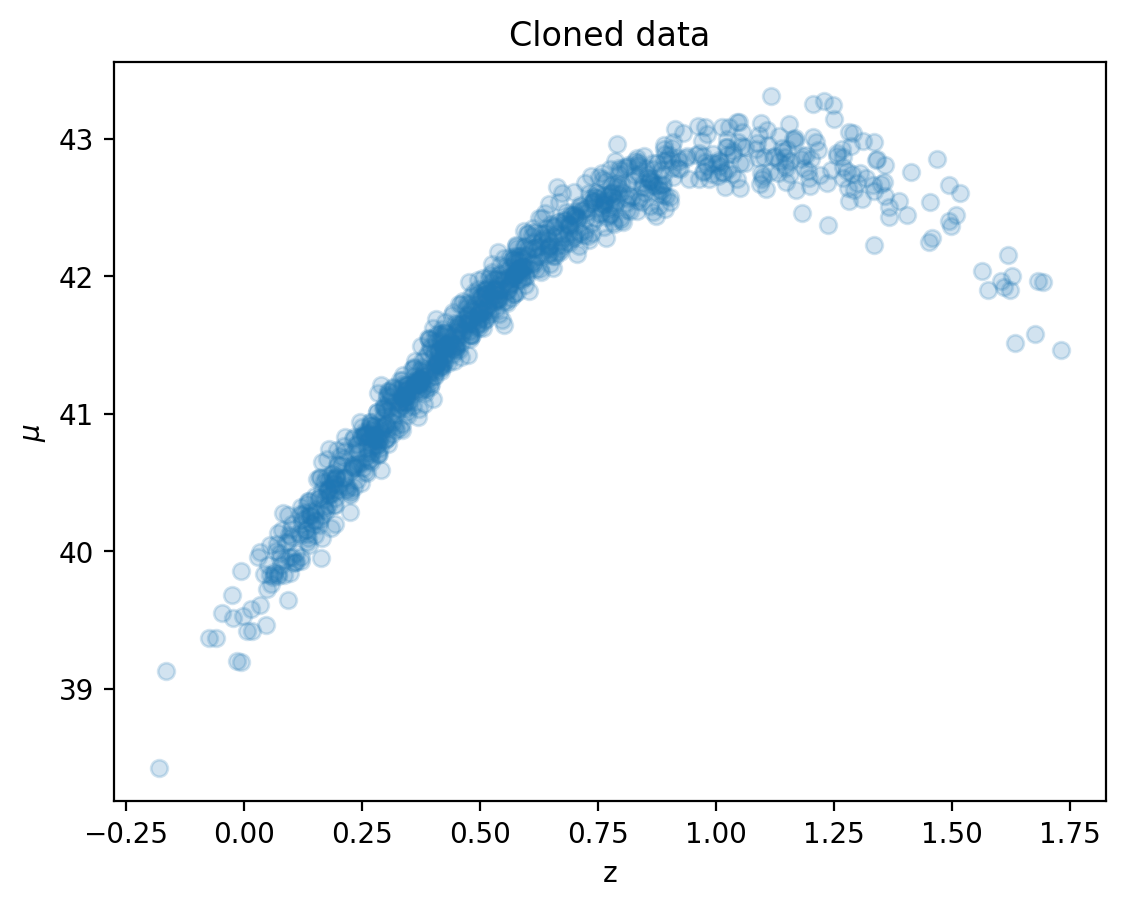

In [242]:
N = 1000
new_z_samples = kde.sample(N)

mu_gpr=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gp.predict([[z]], 
                           return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))
    
    
plt.scatter(new_z_samples,mu_gpr,alpha=0.2)

plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.title("Cloned data");